# STARTER

In [1]:
import sys
import pathlib

# Get project root (parent of generation/)
project_root = pathlib.Path().resolve().parent
sys.path.insert(0, str(project_root))

# MANIFESTO

In [2]:
from scripts.utils.logger import logger

In [3]:
logger_params = {
    "main_folder": "/home/think/Desktop/strats",
    "experiment_name": "LSTM_multivariate_1_strats",
    "date": "2025-10-11",
    "iteration": 1,
    "description": (
        "Se entrenara una LSTM con lorenz63 canonico caotico"
        "en modo multivariable 1 (all for one) para las 5 strategies,"
        "el proposito es que podamos dejar una plantilla"
    )
}

In [4]:
exp_folder, manifesto_path = logger(logger_params)
print(f"Experiment folder created at: {exp_folder}")
print(f"Manifesto written to: {manifesto_path}")

Experiment folder created at: /home/think/Desktop/strats/LSTM_multivariate_1_strats_2025-10-11_iter1
Manifesto written to: /home/think/Desktop/strats/LSTM_multivariate_1_strats_2025-10-11_iter1/manifesto.txt


# DATA

In [5]:
from scripts.data_generation.binder import Binder
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scripts.data_generation.tsdg import DynamicalSystem
from sklearn.preprocessing import MinMaxScaler

# --- Data Generation ---
model_name = 'lorenz63'
sigma = 10 
beta = 8/3
rho = 28
params = (sigma, beta, rho)
binder = Binder("scripts.systems.lorenz63", "lorenz63", params)
binder.import_module()      
model_fixed = binder.fixer()
t_span = (0, 100)
t_eval = np.linspace(t_span[0], t_span[1], 1000)
y0 = np.array([0.1, 0.1, 0.1])
ds1 = DynamicalSystem(model_fixed, y0, t_eval, notebook = True)
_ = ds1.solve()

# --- Convert to dataframe ---
sample = ds1.to_dataframe()

# Train and Test Split
Full = sample.values
n_samples = len(Full)

train_size = int(0.60 * n_samples)   # 70% for training
val_size = int(0.20 * n_samples)     # 10% for validation
test_size = n_samples - train_size - val_size  # remaining 20% for testing

train_data = Full[:train_size]
val_data = Full[train_size:train_size+val_size]
test_data = Full[train_size+val_size:]

# --- Scaling ---
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data.reshape(-1, 1)).flatten()
val_scaled = scaler.transform(val_data.reshape(-1, 1)).flatten()
test_scaled = scaler.transform(test_data.reshape(-1, 1)).flatten()

# # We fit on train but immediately transform test here for simplicity
# test_scaled  = scaler.transform(test_data.reshape(-1, 1)).flatten()
# # If you want the prediction back in original units:
# # yhat = scaler.inverse_transform(yhat_scaled)

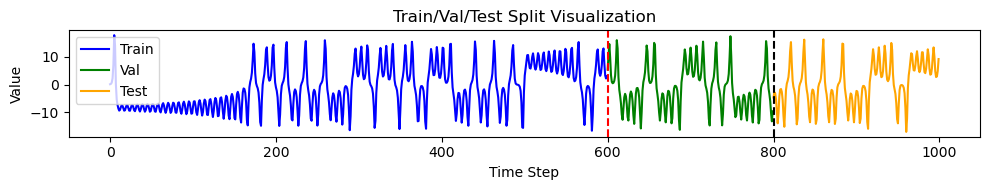

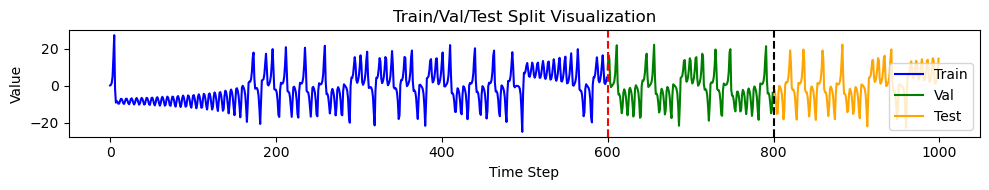

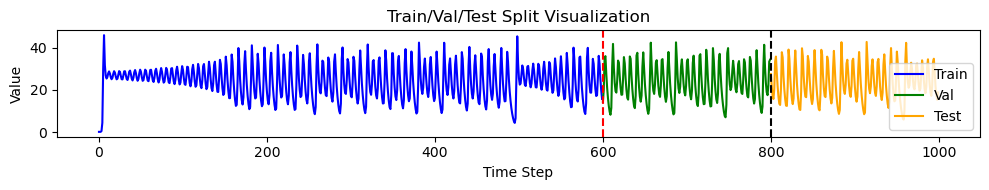

In [6]:
for i in range(len(sample.columns)):
    # Define x-axis ranges based on the lengths
    train_end = len(train_data[:,i])
    val_end = len(train_data[:,i]) + len(val_data[:,i])
    x_train = np.arange(train_end)
    x_val =np.arange(train_end, train_end + len(val_data[:,i]))
    x_test = np.arange(val_end, val_end + len(test_data[:,i]))
    # Plot
    plt.figure(figsize=(10, 2))
    plt.plot(x_train, train_data[:,i], label='Train', color='blue')
    plt.plot(x_val, val_data[:,i], label='Val', color='green')
    plt.plot(x_test, test_data[:,i], label='Test', color='orange')

    # Optional vertical line to indicate the split
    plt.axvline(x=train_end, color='red', linestyle='--') #label='Train/Test Split'
    plt.axvline(x=val_end, color='black', linestyle='--') #label='Train/Test Split'
    plt.legend()
    plt.title("Train/Val/Test Split Visualization")
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.tight_layout()
    plt.show()

# NO SE PUEDE
RECURSIVE-MULTIVARIATE-ALL_FOR_ONE

In [7]:
from numpy import array
# define input sequence
in_seq1 = array([i for i in range(10, 100, 10)])
in_seq2 = array([i for i in range(15, 100, 10)])
out_seq = array([in_seq1[i] + in_seq2[i] for i in range(len(in_seq1))])

from numpy import hstack
# convert to [row, columns] structure

in_seq1 = in_seq1.reshape((len(in_seq1), 1))
in_seq2 = in_seq2.reshape((len(in_seq2), 1))
out_seq = out_seq.reshape((len(out_seq), 1))

#horizontally stack columns
dataset = hstack((in_seq1, in_seq2, out_seq))

In [8]:
# split a multivariate sequence into samples
def split_sequences(sequences, n_steps):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps
        # check if we are beyond the dataset
        if end_ix > len(sequences):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y =  sequences[i:end_ix, :-1], sequences[end_ix-1, -1]
        X.append(seq_x)
        y.append(seq_y)

    return array(X), array(y)

In [9]:
# split a multivariate sequence into samples
def split_sequences_v2(sequences, n_all_features_in, n_single_feature_out, n_steps):
    j = n_all_features_in
    k = n_single_feature_out

    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps
        # check if we are beyond the dataset
        if end_ix > len(sequences):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y =  sequences[i:end_ix, :j], sequences[end_ix-1, k-1:k]

        X.append(seq_x)
        y.append(seq_y)

    return array(X), array(y)

In [12]:
# choose a number of features
rows, cols = dataset.shape
n_all_features_in = 1
n_single_feature_out = 1
# choose a number of time steps
n_steps = 3
# # convert into input/output
# X,  y = split_sequences_v2(dataset, n_all_features_in, n_single_feature_out,  n_steps)

In [13]:
# choose a number of time steps
n_features = 2
n_steps = 3
# convert into input/output
X,  y = split_sequences(dataset, n_steps)

In [14]:
for i in range(len(X)):
    print(X[i], y[i])

[[10 15]
 [20 25]
 [30 35]] 65
[[20 25]
 [30 35]
 [40 45]] 85
[[30 35]
 [40 45]
 [50 55]] 105
[[40 45]
 [50 55]
 [60 65]] 125
[[50 55]
 [60 65]
 [70 75]] 145
[[60 65]
 [70 75]
 [80 85]] 165
[[70 75]
 [80 85]
 [90 95]] 185


In [15]:
print(X.shape)
print(y.shape)

(7, 3, 2)
(7,)


In [20]:
# Vanilla
from keras.models import Sequential
from keras.layers import LSTM, Dense

def vanilla_lstm(n_steps, n_features, units=100):
    """Return a compiled vanilla LSTM model."""
    model = Sequential()
    model.add(LSTM(units, activation='relu', input_shape=(n_steps, n_features)))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

In [33]:
model_recursive = vanilla_lstm(n_steps, n_features)
model_recursive.fit(X, y, epochs=100, verbose=0)

/home/think/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [31]:
from sklearn import metrics
from scipy.stats import skew
import numpy as np


def recursive_OS_predictions(starter_sample, horizon, model, scaler = None):
    # Initialize input, start with the last value of the training data
    uno = starter_sample 
    # List to store predictions
    predictions = []
    # Loop to predict one step at a time
    for i in range(horizon):
        yhat_scaled = model.predict(uno, verbose=0)
        # Save prediction in original units
        if scaler is not None:
            yhat_inv = scaler.inverse_transform(yhat_scaled)
            predictions.append(yhat_inv[0, 0])
        else:
            predictions.append(yhat_scaled[0, 0])

        # Feed back the scaled value to the model
        uno = yhat_scaled.reshape((1, n_steps, n_features)) 
     
    # Convert predictions to numpy array
    predictions = np.array(predictions)
    return predictions

In [30]:
array([[80,85], [90,95], [100,105]])

array([[ 80,  85],
       [ 90,  95],
       [100, 105]])

In [35]:
starter_sample = array([[80,85], [90,95], [100,105]])
horizon = 20
recurs_preds_1 = recursive_OS_predictions(starter_sample, horizon, model_recursive, scaler = None)

ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=int64)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [17]:
model.fit(X, y, epochs =200, verbose=0)

In [34]:
# demonstrate prediction
x_input = array([[80,85], [90,95], [100,105]])
x_input = x_input.reshape((1, n_steps, n_features))
yhat = model_recursive.predict(x_input, verbose = 0)

In [19]:
print(yhat)

[[205.25494]]


In [ ]:
# Plot
plt.plot(test_scaled[:horizon], label='Original (last 20)', marker='o')
plt.plot(recurs_preds_1, label='Predicted', marker='*')
plt.legend()
plt.title('One-Step Recursive Forecasting')
plt.show()

# DIRECT-MULTIVARIATE-ALL_FOR_ONE

In [147]:
from numpy import array
# define input sequence
in_seq1 = array([i for i in range(10, 100, 10)])
in_seq2 = array([i for i in range(15, 100, 10)])
out_seq = array([in_seq1[i] + in_seq2[i] for i in range(len(in_seq1))])

from numpy import hstack
# convert to [row, columns] structure

in_seq1 = in_seq1.reshape((len(in_seq1), 1))
in_seq2 = in_seq2.reshape((len(in_seq2), 1))
out_seq = out_seq.reshape((len(out_seq), 1))

#horizontally stack columns
dataset = hstack((in_seq1, in_seq2, out_seq))

In [148]:
# split a multivariate sequence into samples
def split_sequences(sequences, n_steps, skip):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps
        # check if we are beyond the dataset
        if end_ix > len(sequences)-skip:
            break
        # gather input and output parts of the pattern
        seq_x, seq_y =  sequences[i:end_ix, :-1], sequences[end_ix+skip-1, -1]
        X.append(seq_x)
        y.append(seq_y)

    return array(X), array(y)

In [170]:
# choose a number of time steps
n_features = 2
n_steps = 3
horizon = 5
datasets = {}
for i in range(horizon):
    X, y = split_sequences(dataset, n_steps, i)
    X = X.reshape((X.shape[0], X.shape[1], n_features))
    datasets[i] = (X, y)  # store as tuple

In [171]:
for i in datasets:
    print(i, end=' ')

0 1 2 3 4 

In [173]:
X, y = datasets[4]
print(X.shape)
print(y.shape)
for xi, yi in zip(X, y):
    print(xi,yi)



(3, 3, 2)
(3,)
[[10 15]
 [20 25]
 [30 35]] 145
[[20 25]
 [30 35]
 [40 45]] 165
[[30 35]
 [40 45]
 [50 55]] 185


In [174]:
# Vanilla
from keras.models import Sequential
from keras.layers import LSTM, Dense

def vanilla_lstm(n_steps, n_features, units=100):
    """Return a compiled vanilla LSTM model."""
    model = Sequential()
    model.add(LSTM(units, activation='relu', input_shape=(n_steps, n_features)))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

In [175]:
models = {}
for i, (X, y) in datasets.items():  # i is literally 0, 1, 2...
    model = vanilla_lstm(n_steps, n_features)
    model.fit(X, y, epochs=500, verbose=0)
    models[i] = model  # store the trained model for that step

/home/think/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [177]:
starter_sample = array([[80,85], [90,95], [100,105]]).reshape((1, n_steps, n_features)) 
predictions_direct = []

for i in models:  # skip = number of horizons / models
    model = models[i]
    yhat = model.predict(starter_sample, verbose=0)
    predictions_direct.append(yhat[0, 0])  # flatten the output

In [182]:
predictions_direct

[205.69731, 228.01433, 251.04866, 304.39496, 364.78973]

In [206]:
from numpy import array
# define input sequence
test_seq = array([i for i in range(205, 300, 20)])

In [179]:
test_seq

array([205, 225, 245, 265, 285])

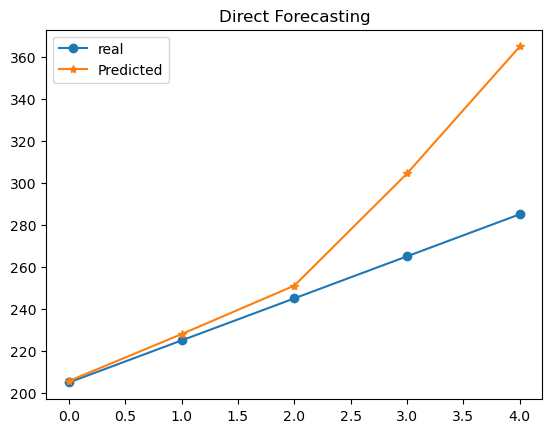

In [180]:
# Plot
plt.plot(test_seq.flatten(), marker='o', label = 'real')
plt.plot(predictions_direct, label='Predicted', marker='*')
plt.legend()
plt.title('Direct Forecasting')
plt.show()

# NO SE PUEDE
DIREC-UNIVARIATE 
Dividir el horizonte $H$ en bloques $B$ de modo que $H/B = N$. Se entrena un modelo para predecir $B$ pasos, y la predicción del bloque se reutiliza como entrada del siguiente bloque hasta alcanzar $H$.  

In [55]:
# univariate data preparation
from numpy import array
#  split a univariate sequence into samples
def split_sequence_direc(sequence, n_steps_in, n_steps_out, skip):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this patter
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # print(i,end_ix)
        # print(end_ix,out_end_ix)
        # check if we are beyond the sequence
        if out_end_ix > len(sequence)- skip:
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[skip+end_ix:skip + out_end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [68]:
# choose a number of time steps
n_steps_in = 3
n_steps_out = 3
skip=0
# split into samples
X, y = split_sequence_direc(train_scaled, n_steps_in, n_steps_out, skip)   

In [70]:
# reshape from [samples, timesteps] into [samples, timesteps, features]
n_features = 1
X = X.reshape((X.shape[0], X.shape[1], n_features))

In [71]:
# Vanilla
from keras.models import Sequential
from keras.layers import LSTM, Dense
def vanilla_lstm_direct(n_steps_in, n_steps_out, n_features, units=100):
    model = Sequential()
    model.add(LSTM(units, activation='relu', input_shape=(n_steps_in, n_features)))
    model.add(Dense(n_steps_out))
    model.compile(optimizer='adam', loss='mse')
    return model

In [85]:
model_direc = vanilla_lstm_direct(n_steps_in, n_steps_out,n_features)
model_direc.fit(X, y, epochs=800, verbose=0)

/home/think/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [86]:
from sklearn import metrics
from scipy.stats import skew
import numpy as np


def direc_predictions(starter_sample, horizon, model, scaler = None):
    # Initialize input, start with the last value of the training data
    n_steps_in = len(starter_sample)
    uno = starter_sample.reshape((1, n_steps_in, n_features)) 
    # List to store predictions
    predictions = []
    # Loop to predict one step at a time
    for i in range(0, horizon, len(starter_sample)):
        yhat_scaled = model.predict(uno, verbose=0)
        # Save prediction in original units
        if scaler is not None:
            yhat_inv = scaler.inverse_transform(yhat_scaled)
            predictions.append(yhat_inv)
        else:
            predictions.append(yhat_scaled)

        # Feed back the scaled value to the model
        uno = yhat_scaled.reshape((1, n_steps_in, n_features)) 
     
    # Convert predictions to numpy array
    predictions = np.array(predictions)
    return predictions

In [87]:
starter_sample = train_scaled[-3:] #.reshape((1, n_steps_in, n_features)) 
horizon = 21
direc_preds = direc_predictions(starter_sample, horizon, model_direc, scaler = None)

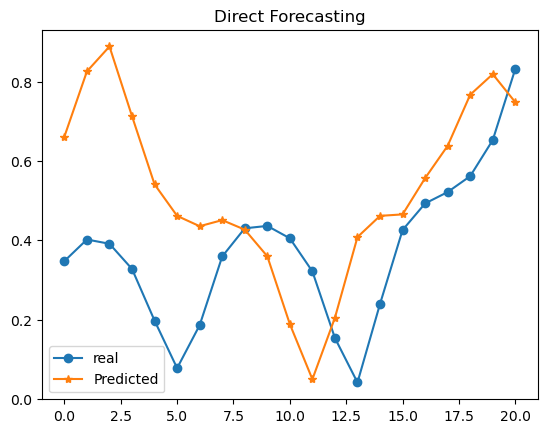

In [88]:
# Plot
plt.plot(test_scaled[:horizon], marker='o', label = 'real')
plt.plot(direc_preds.flatten(), label='Predicted', marker='*')
plt.legend()
plt.title('Direct Forecasting')
plt.show()

# MIMO-UNIVARIATE
Entrenar un único modelo capaz de predecir directamente los $H$ pasos en una sola iteración. 

In [194]:
from numpy import array
from numpy import hstack

# define input sequence
in_seq1 = array([10,20,30, 40, 50, 60,70,80,90])
in_seq2 = array([15,25,35,45,55,65,75,85,95])
out_seq = array([in_seq1[i] + in_seq2[i] for i in range(len(in_seq1))])
# convert to [rows, columns] structure
in_seq1 = in_seq1.reshape((len(in_seq1), 1))
in_seq2 = in_seq2.reshape((len(in_seq2), 1))
out_seq = out_seq.reshape((len(out_seq), 1))
# horizontally stack columns
dataset = hstack((in_seq1, in_seq2, out_seq))

In [195]:
# multivariate multi-step stacked lstm example

from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense

# split a multivaraite sequence into samples
def split_sequences(sequences, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out - 1
        # check if we are beyond the dataset
        if out_end_ix > len(sequences):
            break
        # gather input and outpu parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :-1], sequences[end_ix-1:out_end_ix, -1]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [200]:
# choose a number of time steps
n_steps_in, n_steps_out = 3, 4
# convert into input/output
X, y = split_sequences(dataset, n_steps_in, n_steps_out)

In [201]:
for i in range(len(X)):
    print(X[i], y[i])

[[10 15]
 [20 25]
 [30 35]] [ 65  85 105 125]
[[20 25]
 [30 35]
 [40 45]] [ 85 105 125 145]
[[30 35]
 [40 45]
 [50 55]] [105 125 145 165]
[[40 45]
 [50 55]
 [60 65]] [125 145 165 185]


In [202]:
# the dataset knows the number of featrues, e.g. 2
n_features = X.shape[2]

In [ ]:
# define model
model = Sequential()
model.add(LSTM(100, activation='relu', return_sequences=True, input_shape=(n_steps_in, n_features)))
model.add(LSTM(100, activation='relu'))
model.add(Dense(n_steps_out))
model.compile(optimizer='adam', loss='mse')


# Vanilla
from keras.models import Sequential
from keras.layers import LSTM, Dense

def vanilla_lstm(n_steps, n_features, units=100):
    """Return a compiled vanilla LSTM model."""
    model = Sequential()
    model.add(LSTM(units, activation='relu', input_shape=(n_steps, n_features)))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

/home/think/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# fit model
model.fit(X, y, epochs = 200, verbose = 0)

model_recursive = vanilla_lstm(n_steps, n_features)
model_recursive.fit(X, y, epochs=100, verbose=0)

In [ ]:
horizon = 20

In [205]:
# demonstrate prediction
x_input = array([[70,75], [80,85], [90,95]])
x_input = x_input.reshape((1, n_steps_in, n_features))
yhat = model.predict(x_input, verbose = 0)
print(yhat)

[[192.25192 219.34805 245.0686  271.6345 ]]


In [ ]:
# Plot
plt.plot(test_scaled[:horizon], label='Original (last 20)', marker='o')
plt.plot(recurs_preds_1, label='Predicted', marker='*')
plt.legend()
plt.title('One-Step Recursive Forecasting')
plt.show()

# DIRMO-UNIVARIATE
Dividir el horizonte $H$ en bloques $B$ de modo que $H/B = N$, y entrenar $N$ modelos, cada uno encargado de predecir $B$ pasos consecutivos. 

In [7]:
from numpy import array
from numpy import hstack

# define input sequence
in_seq1 = array([i for i in range(10,200,10)])
in_seq2 = array([i for i in range(15,205,10)])
out_seq = array([in_seq1[i] + in_seq2[i] for i in range(len(in_seq1))])
# convert to [rows, columns] structure
in_seq1 = in_seq1.reshape((len(in_seq1), 1))
in_seq2 = in_seq2.reshape((len(in_seq2), 1))
out_seq = out_seq.reshape((len(out_seq), 1))
# horizontally stack columns
dataset = hstack((in_seq1, in_seq2, out_seq))

In [8]:
array([i for i in range(15,205,10)])


array([ 15,  25,  35,  45,  55,  65,  75,  85,  95, 105, 115, 125, 135,
       145, 155, 165, 175, 185, 195])

In [9]:
# split a multivaraite sequence into samples
def split_sequences(sequences, n_steps_in, n_steps_out, skip):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out - 1
        # check if we are beyond the dataset
        if out_end_ix > len(sequences) - skip:
            break
        # gather input and outpu parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :-1], sequences[skip + end_ix-1: skip + out_end_ix, -1]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [10]:
n_features = 2
# choose a number of time steps
n_steps_in = 3
n_steps_out = 2
horizon = 4
datasets = {}
for i in range(0, horizon, n_steps_out):
    skip = i
    X, y = split_sequences(dataset, n_steps_in, n_steps_out, skip)
    X = X.reshape((X.shape[0], X.shape[1], n_features))
    datasets[i] = (X, y)  # store as tuple

In [11]:
for i in datasets:
    X,y = datasets[i]
    print(X.shape, y.shape)

(16, 3, 2) (16, 2)
(14, 3, 2) (14, 2)


In [328]:
for i in datasets:
    print(i, end = ' ')

0 2 

In [339]:
X, y = datasets[0]
print(X.shape)
print(y.shape)
for xi, yi in zip(X, y):
    print(xi,yi)

(6, 3, 2)
(6, 2)
[[10 15]
 [20 25]
 [30 35]] [65 85]
[[20 25]
 [30 35]
 [40 45]] [ 85 105]
[[30 35]
 [40 45]
 [50 55]] [105 125]
[[40 45]
 [50 55]
 [60 65]] [125 145]
[[50 55]
 [60 65]
 [70 75]] [145 165]
[[60 65]
 [70 75]
 [80 85]] [165 185]


In [330]:
# Vanilla
from keras.models import Sequential
from keras.layers import LSTM, Dense

def vanilla_lstm(n_steps_in, n_steps_out, n_features, units=100):
    """Return a compiled vanilla LSTM model."""
    model = Sequential()
    model.add(LSTM(units, activation='relu', input_shape=(n_steps_in, n_features)))
    model.add(Dense(n_steps_out))
    model.compile(optimizer='adam', loss='mse')
    return model

In [331]:
models = {}
for i, (X, y) in datasets.items():  # i is literally 0, 1, 2...
    model = vanilla_lstm(n_steps_in, n_steps_out ,n_features)
    model.fit(X, y, epochs=800, verbose=0)
    models[i] = model  # store the trained model for that step

/home/think/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [365]:
starter_sample = array([[80,85], [90,95], [100,105]]).reshape((1, n_steps_in, n_features)) 
predictions_direct = []

for i in models:  # skip = number of horizons / models
    model = models[i]
    yhat = model.predict(starter_sample, verbose=0)
    predictions_direct.append(yhat[0].tolist())  # flatten the output

predictions_direct = np.array(predictions_direct)

In [366]:
predictions_direct

array([[207.28565979, 228.84255981],
       [271.2093811 , 301.95587158]])

In [367]:
from numpy import array
# define input sequence
test_seq = array([i for i in range(205, 285, 20)])
test_seq

array([205, 225, 245, 265])

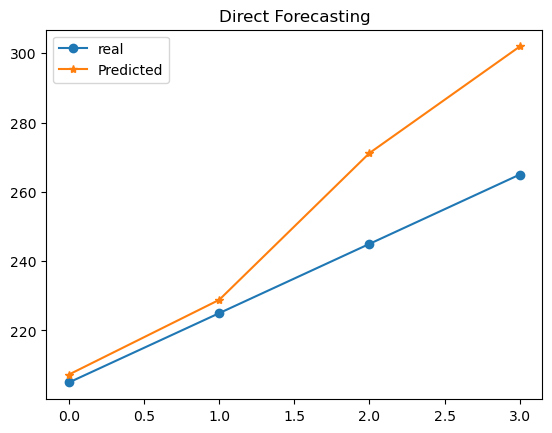

In [368]:
# Plot
plt.plot(test_seq.flatten(), marker='o', label = 'real')
plt.plot(predictions_direct.flatten(), label='Predicted', marker='*')
plt.legend()
plt.title('Direct Forecasting')
plt.show()

In [129]:
# univariate data preparation
from numpy import array
#  split a univariate sequence into samples
def split_sequence_dirMO(sequence, n_steps_in, n_steps_out, skip):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this patter
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # print(i,end_ix)
        # print(end_ix,out_end_ix)
        # check if we are beyond the sequence
        if out_end_ix > len(sequence)- skip:
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[skip+end_ix:skip + out_end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [166]:
# choose a number of time steps
n_steps_in = 5
n_steps_out = 5
horizon = 20
datasets = {}
for i in range(0,horizon, n_steps_out):
    X, y = split_sequence_dirMO(train_scaled, n_steps_in, n_steps_out, i)
    n_features = 1
    X = X.reshape((X.shape[0], X.shape[1], n_features))
    datasets[i] = (X, y)  # store as tuple

In [168]:
# Vanilla
from keras.models import Sequential
from keras.layers import LSTM, Dense
def vanilla_lstm_dirMO(n_steps_in, n_steps_out, n_features, units=100):
    model = Sequential()
    model.add(LSTM(units, activation='relu', input_shape=(n_steps_in, n_features)))
    model.add(Dense(n_steps_out))
    model.compile(optimizer='adam', loss='mse')
    return model

In [169]:
models = {}
for i, (X, y) in datasets.items():  # i is literally 0, 1, 2...
    model = vanilla_lstm_dirMO(n_steps_in, n_steps_out, n_features, units = 100)
    model.fit(X, y, epochs=500, verbose=0)
    models[i] = model  # store the trained model for that step

/home/think/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [171]:
from sklearn import metrics
from scipy.stats import skew
import numpy as np
# Initialize input
starter_sample = train_scaled[-5:]
n_steps_in = len(starter_sample)
uno = starter_sample.reshape((1, n_steps_in, n_features)) 
# List to store predictions
predictions = []
# Loop to predict one step at a time
for i in models:
    model = models[i]
    yhat_scaled = model.predict(uno, verbose=0) 
    predictions.append(yhat_scaled)
# Convert predictions to numpy array
predictions = np.array(predictions)

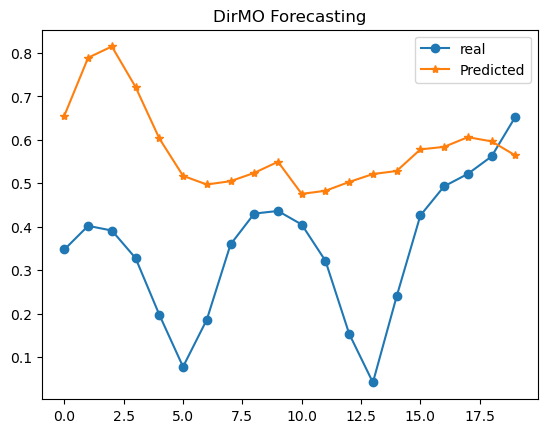

In [172]:
# Plot
plt.plot(test_scaled[:horizon], marker='o', label = 'real')
plt.plot(predictions.flatten(), label='Predicted', marker='*')
plt.legend()
plt.title('DirMO Forecasting')
plt.show()